In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from core.hydrodispatchenv import HydroDispatchEnv

In [ ]:
df = pd.read_csv("../data/synthetic_inflow_1yr.csv")
inflow_data = df["inflow_m3s"].values
print(inflow_data)
env = HydroDispatchEnv(inflow_data=inflow_data)


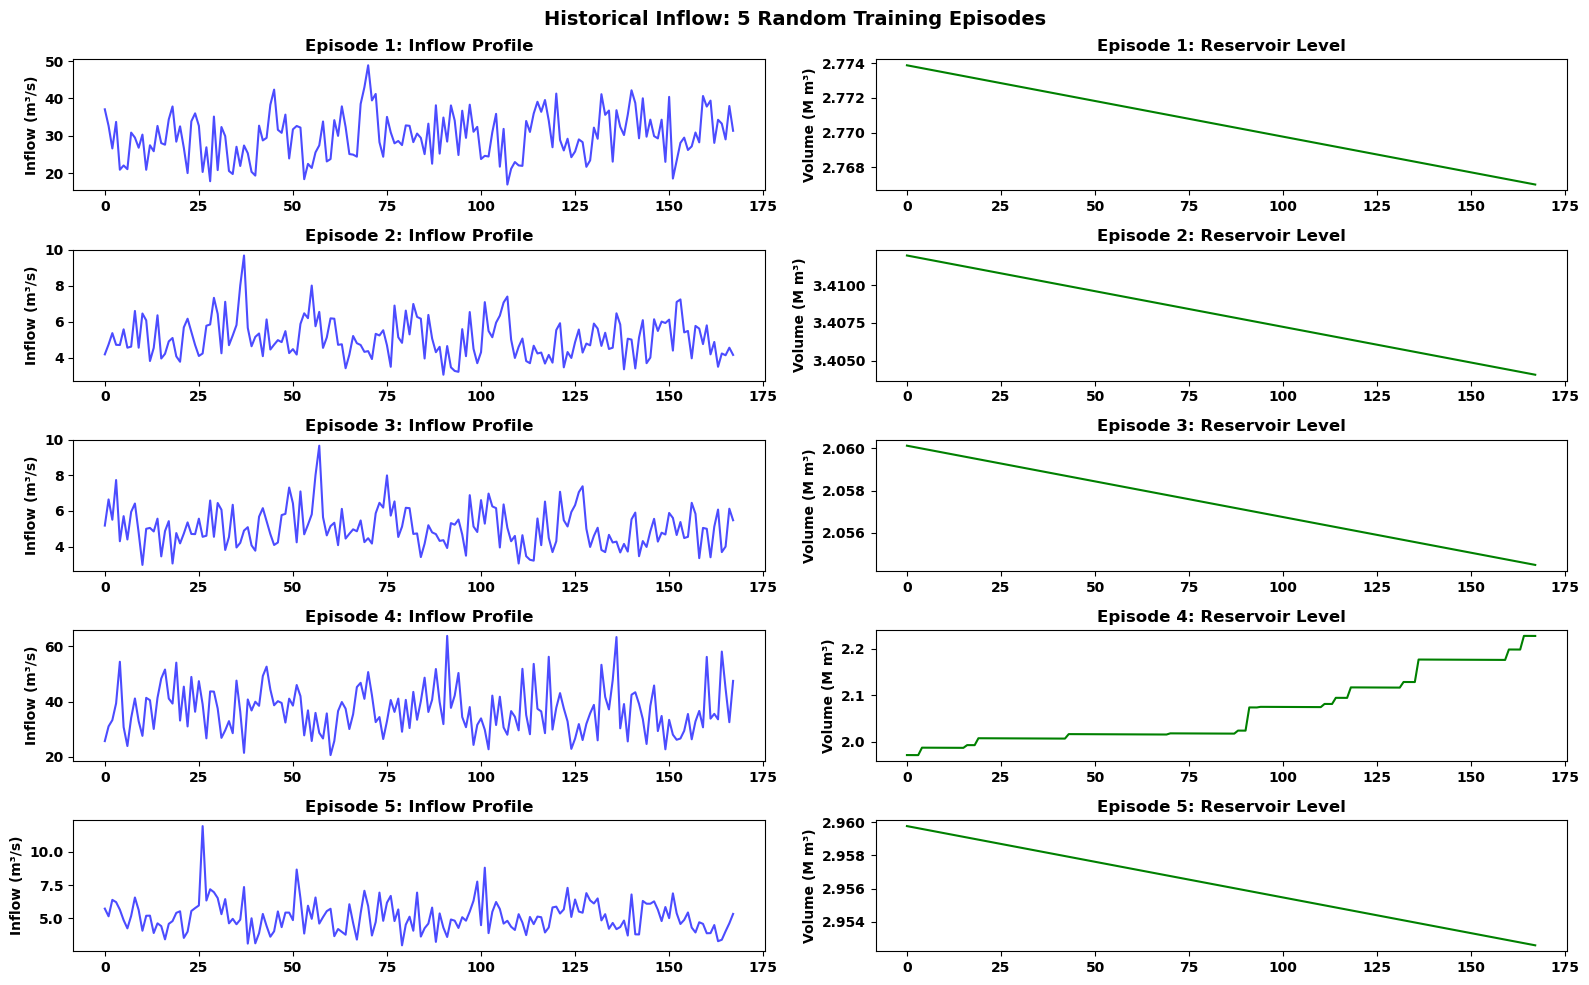

In [13]:
n = 5
fig, axes = plt.subplots(n, 2, figsize=(16, 10))

for ep in range(n):
    obs, info = env.reset(seed=ep * 10)
    inflows, volumes = [], []

    for step in range(env.HOURS_PER_EPISODE):
        current_inflow = env._get_current_inflow()
        inflows.append(current_inflow)
        action = np.array([current_inflow])
        obs, reward, term, trunc, info = env.step(action)
        volumes.append(info["volume_m3"])
        if term: break

    axes[ep, 0].plot(inflows, 'b-', alpha=0.7)
    axes[ep, 0].set_ylabel("Inflow (m³/s)")
    axes[ep, 0].set_title(f"Episode {ep+1}: Inflow Profile")

    axes[ep, 1].plot([v/1e6 for v in volumes], 'g-')
    axes[ep, 1].set_ylabel("Volume (M m³)")
    axes[ep, 1].set_title(f"Episode {ep+1}: Reservoir Level")

plt.suptitle(f"Historical Inflow: {n} Random Training Episodes", fontsize=14)
plt.tight_layout()
plt.show()

# Ep 4 Spike Explanation: The dummy agent requests turbine discharge == current_inflow,
# dummy not RL; to assess baseline physics
# When inflow > 50 m3/s (TURBINE_Q_MAX), the env physically clips the discharge to 50.
# The excess water has nowhere to go but the reservoir, proving our conservation of mass physics works perfectly.

# training still remains (PPO)